# 03 — Error Analysis & Business Translation

Where does the XGBoost model (the best performer from `02_modeling.ipynb`, holdout WAPE 0.437) fail, and what should a demand planning team actually do with that? This notebook breaks down error by event/segment/store, visualizes representative forecasts, translates residual uncertainty into safety-stock recommendations, and closes with concrete ops recommendations.

In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from metrics import rmse, mae, wape

FIG_DIR = Path("../figures")

df = pd.read_parquet("../data/processed/modeling_table.parquet")
xgb = pd.read_parquet("../data/processed/xgb_holdout_preds.parquet")
seg = pd.read_parquet("../data/processed/sku_segments.parquet")[["store_id", "item_id", "segment"]]

xgb = xgb.merge(seg, on=["store_id", "item_id"])
xgb = xgb.merge(df[["store_id", "item_id", "date", "is_event"]], on=["store_id", "item_id", "date"])
xgb["residual"] = xgb["sales"] - xgb["sales_pred"]

print(f"{len(xgb):,} holdout predictions | overall WAPE: {wape(xgb['sales'], xgb['sales_pred']):.3f}")

8,400 holdout predictions | overall WAPE: 0.437


## 1. Where does XGBoost fail?

WAPE broken down by event days, SKU segment, and store.

False       0.441
True        0.418
stable      0.354
volatile    0.626
CA_1        0.423
TX_1        0.454
Name: WAPE, dtype: float64


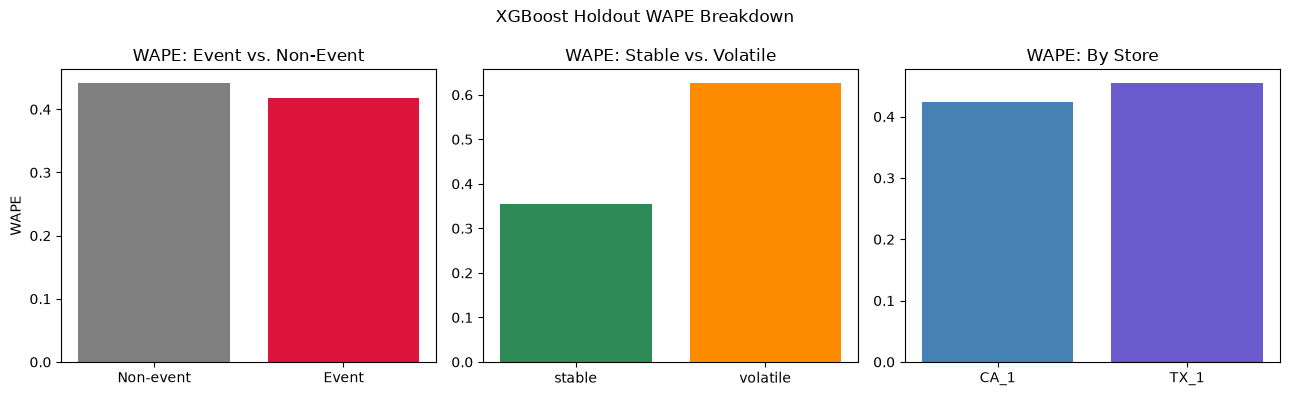

In [2]:
breakdown = pd.concat([
    xgb.groupby("is_event").apply(lambda d: wape(d["sales"], d["sales_pred"])).rename("WAPE").rename_axis("event"),
    xgb.groupby("segment").apply(lambda d: wape(d["sales"], d["sales_pred"])).rename("WAPE").rename_axis("segment"),
    xgb.groupby("store_id").apply(lambda d: wape(d["sales"], d["sales_pred"])).rename("WAPE").rename_axis("store"),
])
print(breakdown.round(3))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

event_wape = xgb.groupby("is_event").apply(lambda d: wape(d["sales"], d["sales_pred"]))
axes[0].bar(["Non-event", "Event"], event_wape.values, color=["gray", "crimson"])
axes[0].set_title("WAPE: Event vs. Non-Event")
axes[0].set_ylabel("WAPE")

seg_wape = xgb.groupby("segment").apply(lambda d: wape(d["sales"], d["sales_pred"]))
axes[1].bar(seg_wape.index, seg_wape.values, color=["seagreen", "darkorange"])
axes[1].set_title("WAPE: Stable vs. Volatile")

store_wape = xgb.groupby("store_id").apply(lambda d: wape(d["sales"], d["sales_pred"]))
axes[2].bar(store_wape.index, store_wape.values, color=["steelblue", "slateblue"])
axes[2].set_title("WAPE: By Store")

fig.suptitle("XGBoost Holdout WAPE Breakdown")
fig.tight_layout()
fig.savefig(FIG_DIR / "06_wape_breakdown.png", dpi=150)
plt.show()

**Takeaway:** SKU segment is by far the dominant error driver — volatile-segment WAPE (0.626) is ~1.8x stable-segment WAPE (0.354), while event days are actually forecast *slightly better* than non-event days (0.418 vs 0.441, likely because the event/SNAP features give the model useful signal precisely when it needs it) and the two stores are close (CA_1 0.423, TX_1 0.454). **Practically: error is a SKU-volatility problem, not a calendar or store-location problem** — mitigation effort should target volatile SKUs specifically, not particular days or stores.

## 2. Forecast vs. actual: three representative SKUs

- **Well-predicted**: FOODS_3_555 (CA_1) — steady mid-volume seller, WAPE 0.15
- **Poorly predicted**: FOODS_3_760 (TX_1) — low-volume, noisy demand, WAPE 2.01
- **Intermittent**: FOODS_3_711 (CA_1) — 46% zero-sales days, WAPE 0.98

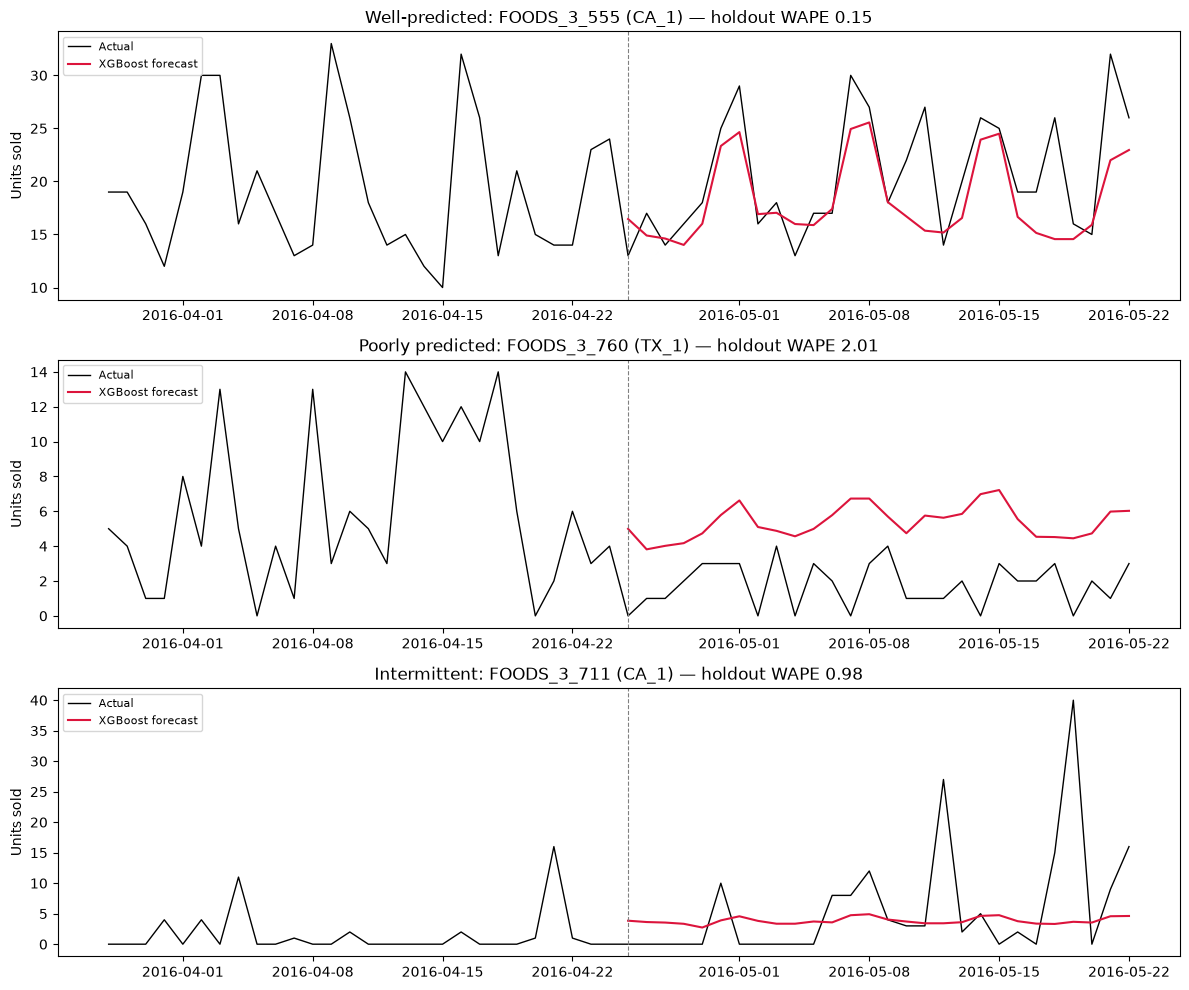

In [3]:
examples = [
    ("CA_1", "FOODS_3_555", "Well-predicted"),
    ("TX_1", "FOODS_3_760", "Poorly predicted"),
    ("CA_1", "FOODS_3_711", "Intermittent"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
for ax, (store, item, label) in zip(axes, examples):
    hist = df[(df["store_id"] == store) & (df["item_id"] == item)].sort_values("date").tail(56)
    pred = xgb[(xgb["store_id"] == store) & (xgb["item_id"] == item)].sort_values("date")
    holdout_start = pred["date"].min()

    ax.plot(hist["date"], hist["sales"], label="Actual", color="black", linewidth=1)
    ax.plot(pred["date"], pred["sales_pred"], label="XGBoost forecast", color="crimson", linewidth=1.5)
    ax.axvline(holdout_start, color="gray", linestyle="--", linewidth=0.8)
    sku_wape = wape(pred["sales"], pred["sales_pred"])
    ax.set_title(f"{label}: {item} ({store}) — holdout WAPE {sku_wape:.2f}")
    ax.set_ylabel("Units sold")
    ax.legend(loc="upper left", fontsize=8)

fig.tight_layout()
fig.savefig(FIG_DIR / "07_forecast_vs_actual.png", dpi=150)
plt.show()

**Takeaway:** The well-predicted SKU shows the model tracking weekly seasonality closely once demand is steady and high-volume; the poorly-predicted SKU shows the opposite failure mode — the forecast sits flat around 4-7 units while actual demand is mostly 0-4 with occasional dips to zero, so the model persistently over-predicts a low-volume, noisy series it has little signal for; the intermittent SKU shows the forecast smoothing over zero-sales days into a small positive number (correct expected-value behavior) but completely missing the one large demand spike (40 units) — a pattern worth explaining to planners so they don't lose trust in the model over normal intermittent noise, while recognizing it will never catch rare spikes from lagged features alone.

## 3. Safety stock under different service levels

Using the holdout residual std per SKU (σ_error = std of actual − predicted over the 28 holdout days) as the demand-forecast-error input to the standard safety-stock formula:

$$SS = z \times \sigma_{error} \times \sqrt{\text{lead time}}$$

with a 7-day lead time, for service levels 95% (z=1.65) and 99% (z=2.33).

In [4]:
LEAD_TIME_DAYS = 7
Z_SCORES = {"95%": 1.65, "99%": 2.33}

sigma_error = xgb.groupby(["store_id", "item_id", "segment"])["residual"].std().reset_index()
sigma_error = sigma_error.rename(columns={"residual": "sigma_error"})

for label, z in Z_SCORES.items():
    sigma_error[f"safety_stock_{label}"] = z * sigma_error["sigma_error"] * np.sqrt(LEAD_TIME_DAYS)

sigma_error.to_csv("../data/processed/safety_stock.csv", index=False)

segment_summary = sigma_error.groupby("segment")[["safety_stock_95%", "safety_stock_99%"]].agg(["sum", "mean"])
segment_summary.round(1)

safety_stock_95%       safety_stock_99%      
                      sum  mean              sum  mean
segment                                               
stable             2889.7  19.3           4080.6  27.2
volatile           2218.0  14.8           3132.1  20.9

Total safety stock across all 300 series: 5108 units (95%) -> 7213 units (99%), a 41.2% increase


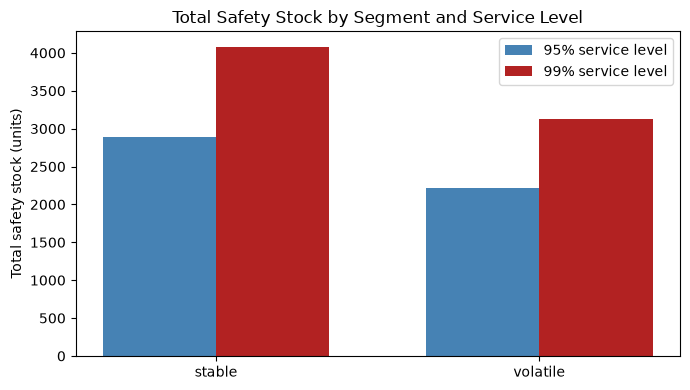

In [5]:
totals = sigma_error[["safety_stock_95%", "safety_stock_99%"]].sum()
pct_increase = (totals["safety_stock_99%"] / totals["safety_stock_95%"] - 1) * 100
ss_95 = totals["safety_stock_95%"]
ss_99 = totals["safety_stock_99%"]
print(f"Total safety stock across all 300 series: {ss_95:.0f} units (95%) "
      f"-> {ss_99:.0f} units (99%), a {pct_increase:.1f}% increase")

fig, ax = plt.subplots(figsize=(7, 4))
seg_totals = sigma_error.groupby("segment")[["safety_stock_95%", "safety_stock_99%"]].sum()
x = np.arange(len(seg_totals))
width = 0.35
ax.bar(x - width/2, seg_totals["safety_stock_95%"], width, label="95% service level", color="steelblue")
ax.bar(x + width/2, seg_totals["safety_stock_99%"], width, label="99% service level", color="firebrick")
ax.set_xticks(x)
ax.set_xticklabels(seg_totals.index)
ax.set_ylabel("Total safety stock (units)")
ax.set_title("Total Safety Stock by Segment and Service Level")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "08_safety_stock.png", dpi=150)
plt.show()

**Takeaway:** Moving from 95% to 99% service level increases total safety stock by 41% uniformly across both segments — a mechanical consequence of the z-score ratio (2.33/1.65 ≈ 1.41), not a segment-specific effect. More notable: **stable-segment SKUs carry more total absolute safety stock (2,890 units) than volatile-segment SKUs (2,218 units) at 95%**, even though their *relative* forecast error (WAPE) is much lower — because stable SKUs sell roughly 2.3x more volume on average (10.9 vs 4.8 units/day), so their absolute forecast error, and therefore absolute safety stock, is still larger in raw units. **Relative accuracy (WAPE) and absolute inventory risk (safety stock units) are different questions — a low-WAPE SKU can still be the bigger inventory dollar risk if it's high-volume.**

## 4. Business recommendations

1. **Deploy XGBoost as the primary forecasting model**, replacing the moving-average baseline — it delivers a ~7.6% WAPE improvement overall and improves both segments, not just the easy one. Keep the 28-day moving average as a fallback for any SKU where the model can't be scored (e.g. brand-new items with no lag history).

2. **Route volatile-segment SKUs (150 of 300 series, WAPE 0.626) to manual planner review**, not full automation. These are disproportionately low-volume, intermittent items where the model has little signal — the forecast-vs-actual plots show it collapsing to a flat estimate rather than capturing real spikes. A human-in-the-loop check for these SKUs before finalizing purchase orders is cheaper than the stockout/overstock risk of trusting the model blindly here.

3. **Set service levels by segment, not uniformly**: because stable SKUs are higher-volume, their absolute safety-stock (dollar and shelf-space) cost of a service-level bump is larger in raw units even though they're the "easier" segment to forecast. A 99% service level for high-volume stable SKUs is a meaningfully bigger inventory commitment than the same target for volatile SKUs — worth a deliberate, SKU-tier-specific service-level policy rather than one blanket target.

4. **Don't over-interpret single-day misses on intermittent SKUs.** The model's expected-value forecast on a zero-heavy series will look "wrong" on any individual day almost by construction (e.g. FOODS_3_711 alternates zero and nonzero days). Evaluate these SKUs on rolling multi-day or weekly totals, not day-by-day accuracy, to avoid planners losing confidence in an otherwise-working model.